# GPU Renderer Orientation & Color Verification
This notebook verifies the `ACESGPURenderer` implementation against a CPU-based Reference (OpenImageIO) to ensure correct orientation (no flipping) and color accuracy.


In [6]:
import os
import sys

# Add project src to path
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import OpenImageIO as oiio
import PyOpenColorIO as ocio

# Set the OCIO config to the local project config
ocio_config_path = "/mnt/MKP01/med8_project/LuminaScale/config/aces/studio-config.ocio"
os.environ["OCIO"] = ocio_config_path

# Reload config after setting environment variable
config = ocio.Config.CreateFromFile(ocio_config_path)
ocio.SetCurrentConfig(config)

from luminascale.utils.gpu_renderer import ACESGPURenderer

# Initialize renderer (it should now pick up the config)
renderer = ACESGPURenderer(headless=True)
print(f"GPU Renderer initialized with OCIO: {ocio_config_path}")

GPU Renderer initialized with OCIO: /mnt/MKP01/med8_project/LuminaScale/config/aces/studio-config.ocio


In [11]:
# Define input and config
input_exr = "/mnt/MKP01/med8_project/LuminaScale/dataset/temp/aces/10_0.exr"
input_cs = "ACES2065-1"

# Automatically find valid display and view
config = ocio.GetCurrentConfig()
displays = list(config.getDisplays())
display = displays[0] if displays else "sRGB"
views = list(config.getViews(display))
view = views[0] if views else "Raw"

print(f"Testing with: {input_exr}")
print(f"Detected Display: {display}, Detected View: {view}, Input CS: {input_cs}")

Testing with: /mnt/MKP01/med8_project/LuminaScale/dataset/temp/aces/10_0.exr
Detected Display: sRGB - Display, Detected View: ACES 2.0 - SDR 100 nits (Rec.709), Input CS: ACES2065-1


In [ ]:
# CPU Reference using luminascale.utils.io.oiio_aces_to_display
from luminascale.utils.io import oiio_aces_to_display

# Process using the project's utility function
# Note: we use our detected display/view for consistency
ref_img = oiio_aces_to_display(
    input_exr,
    display=display,
    view=view
)

print(f"ACES to Display (Utility) Shape: {ref_img.shape}")
print(f"ACES to Display stats: min={ref_img.min():.4f}, max={ref_img.max():.4f}")

ACES to Display (Utility) Shape: (3464, 5202, 3)
ACES to Display stats: min=0.0000, max=1.0000


In [16]:
# GPU Render (Processed by ACESGPURenderer)
try:
    # This calls the newly fixed texcoords standard
    gpu_img = renderer.process_image(
        input_exr,
        display=display,
        view=view,
        input_colorspace=input_cs
    )
    
    print(f"GPU Processed Shape: {gpu_img.shape}")
    print(f"GPU Processed stats: min={gpu_img.min():.4f}, max={gpu_img.max():.4f}")
except Exception as e:
    print(f"GPU Rendering Error: {e}")
    gpu_img = None

GPU Processed Shape: (3464, 5202, 3)
GPU Processed stats: min=0.0000, max=1.0000


MSE (CPU vs GPU): 0.000000


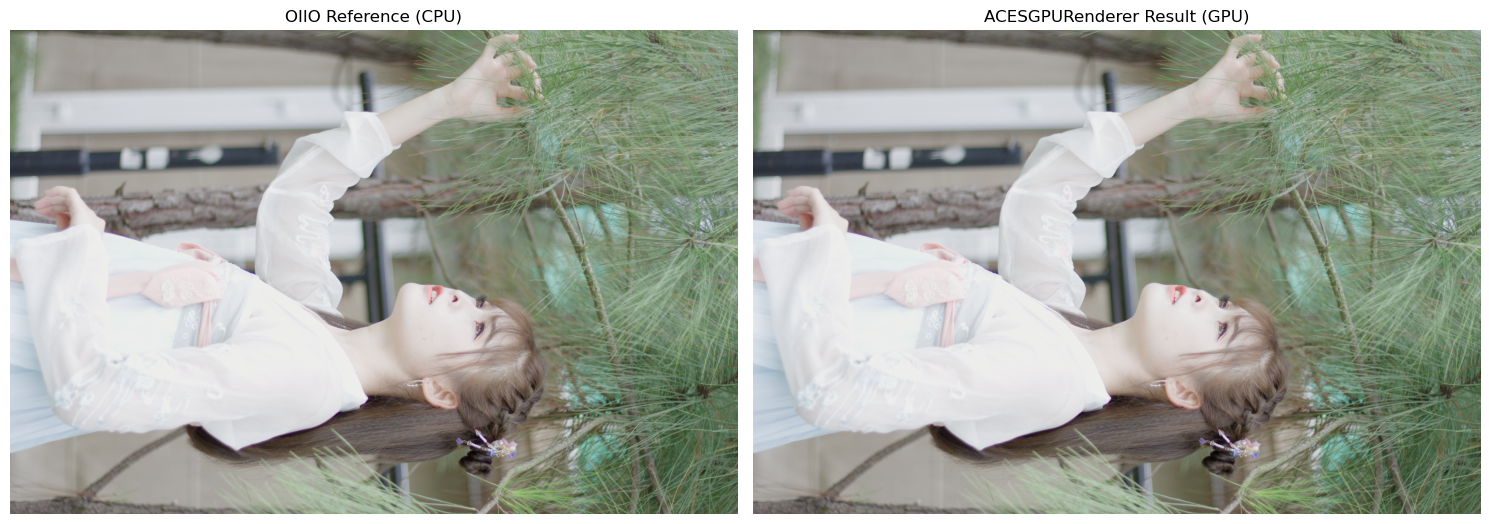

In [17]:
# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# OIIO Ground Truth (CPU)
ax[0].imshow(np.clip(ref_img[:, :, :3], 0, 1))
ax[0].set_title("OIIO Reference (CPU)")
ax[0].axis('off')

# GPU Renderer Result
if gpu_img is not None:
    ax[1].imshow(np.clip(gpu_img, 0, 1))
    ax[1].set_title("ACESGPURenderer Result (GPU)")
    
    # Calculate difference
    # Note: ref_img size vs gpu_img size may slightly differ or match depending on OIIO's internal mapping
    # Assuming standard resize/sampling
    mse = np.mean((ref_img[:gpu_img.shape[0], :gpu_img.shape[1], :3] - gpu_img)**2)
    print(f"MSE (CPU vs GPU): {mse:.6f}")
else:
    ax[1].text(0.5, 0.5, "GPU Render Failed", ha='center', va='center')

ax[1].axis('off')
plt.tight_layout()
plt.show()